# Pneumonia Detection from Chest X-Rays: Custom CNN vs. Transfer Learning

**Course:** Neural Networks and Deep Learning
**Task:** Binary classification (NORMAL vs. PNEUMONIA) on chest X-ray images, using
1. a CNN built from scratch, and
2. a transfer-learning model (pretrained ResNet18),

followed by a comparison of how the results vary between the two approaches.

**Dataset:** [Chest X-Ray Images (Pneumonia)](https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia) (Kermany et al.), downloaded from Kaggle via the Kaggle API.


## 1. Setup — dataset download (no API key needed)

This notebook uses a locally downloaded copy of the dataset — no Kaggle API key required.

**Download it manually:**
1. Go to the dataset page: **https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia**
2. Sign in to Kaggle (free account) if prompted.
3. Click the **Download** button (top-right of the page) — this downloads `archive.zip`
   (sometimes named `chest-xray-pneumonia.zip`), about 1.2 GB.
4. Place the downloaded zip file in the **same folder as this notebook**.
5. Run the extraction cell below — it will unzip it into `data/chest_xray/` automatically and
   works whether the zip contains the folders directly or nests them one level deeper
   (both layouts are common for this particular dataset).

> Mirror: the same dataset is also mirrored at
> **https://data.mendeley.com/datasets/rscbjbr9sj/3** if the Kaggle page is ever unavailable.


In [1]:
# Core / deep-learning imports
import os
import time
import copy
import random
import shutil
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)


Using device: cuda


In [2]:
# Locate a manually downloaded zip next to the notebook (handles either common filename)
ZIP_CANDIDATES = ["archive.zip", "chest-xray-pneumonia.zip"]
ZIP_PATH = next((Path(p) for p in ZIP_CANDIDATES if Path(p).exists()), None)

DATA_ROOT = Path("data")
DATA_DIR = DATA_ROOT / "chest_xray"

if not DATA_DIR.exists():
    if ZIP_PATH is None:
        raise FileNotFoundError(
            "Could not find archive.zip / chest-xray-pneumonia.zip next to this notebook.\n"
            "Download it from https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia "
            "and place the zip in this notebook's folder, then re-run this cell."
        )
    with zipfile.ZipFile(ZIP_PATH, "r") as z:
        z.extractall(DATA_ROOT)
    print(f"Extracted {ZIP_PATH} -> {DATA_ROOT}/")

    # This dataset's zip sometimes nests an extra chest_xray/chest_xray/ level - flatten it.
    nested = DATA_ROOT / "chest_xray" / "chest_xray"
    if nested.exists():
        for item in nested.iterdir():
            shutil.move(str(item), str(DATA_DIR / item.name))
        nested.rmdir()
else:
    print("Dataset already extracted.")

print("Dataset root:", DATA_DIR.resolve())
assert (DATA_DIR / "train").exists() and (DATA_DIR / "test").exists(), \
    "Expected train/ and test/ folders under data/chest_xray/ - check the extracted layout."


Dataset already extracted.
Dataset root: C:\Users\yaksh\Downloads\pneumonia_nndl\data\chest_xray


## 2. Dataset overview

The dataset ships with its own `train` / `val` / `test` split, each containing `NORMAL/` and
`PNEUMONIA/` subfolders of JPEG X-rays. The provided `val` split is tiny (16 images), so we
re-derive a proper validation split from the training data using an 85/15 stratified split,
and keep the original `test` folder untouched as our held-out test set.


In [3]:
TRAIN_DIR = DATA_DIR / "train"
TEST_DIR = DATA_DIR / "test"

for cls in ["NORMAL", "PNEUMONIA"]:
    n_train = len(list((TRAIN_DIR / cls).glob("*.jpeg")))
    n_test = len(list((TEST_DIR / cls).glob("*.jpeg")))
    print(f"{cls:10s} | train: {n_train:5d} | test: {n_test:5d}")


NORMAL     | train:  1341 | test:   234
PNEUMONIA  | train:  3875 | test:   390


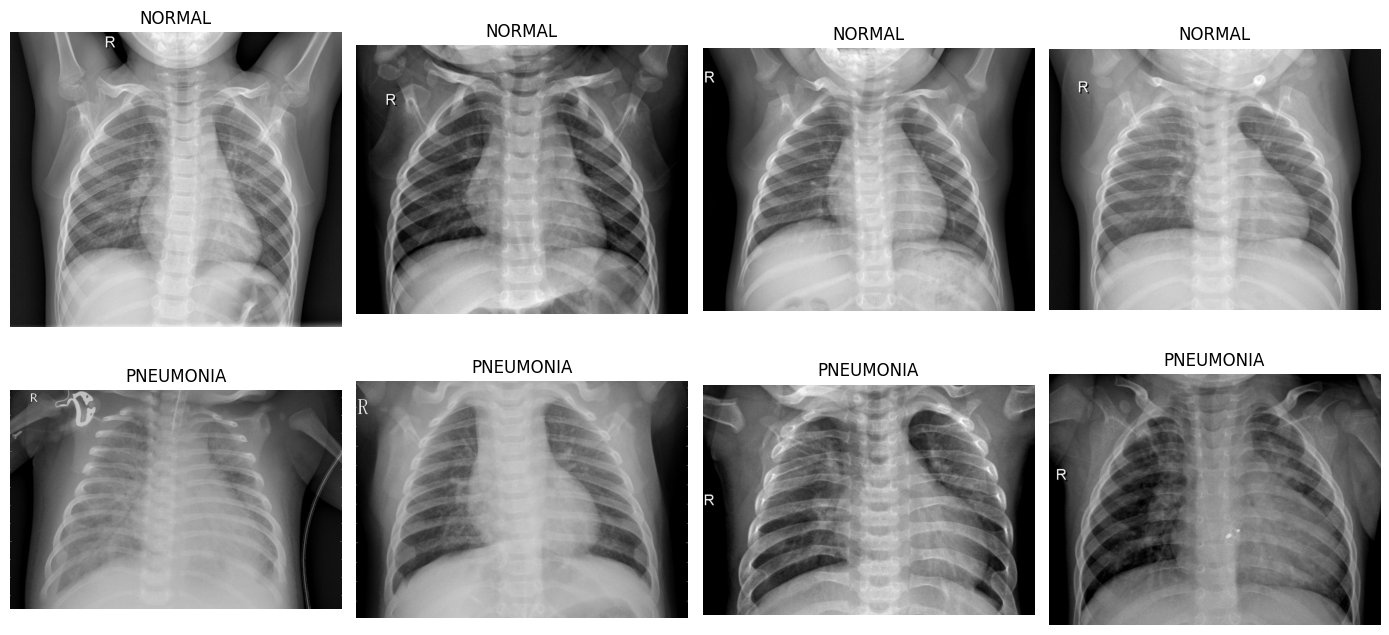

In [4]:
# Peek at a few sample images from each class
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for row, cls in enumerate(["NORMAL", "PNEUMONIA"]):
    sample_files = list((TRAIN_DIR / cls).glob("*.jpeg"))[:4]
    for col, fpath in enumerate(sample_files):
        img = plt.imread(fpath)
        axes[row, col].imshow(img, cmap="gray")
        axes[row, col].set_title(cls)
        axes[row, col].axis("off")
plt.tight_layout()
plt.show()


## 3. Data loading, splitting, and augmentation

- Images are resized to 224x224 and converted to 3-channel tensors (needed for the pretrained
  ResNet18 backbone; the custom CNN uses the same input for a fair, apples-to-apples comparison).
- Light augmentation (random flip, small rotation) is applied to the training split only.
- Normalisation uses ImageNet mean/std so the same pipeline works for both models.


In [5]:
IMG_SIZE = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.3),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

full_train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
test_dataset = datasets.ImageFolder(TEST_DIR, transform=eval_transform)

print("Classes:", full_train_dataset.classes)  # ['NORMAL', 'PNEUMONIA']


Classes: ['NORMAL', 'PNEUMONIA']


In [6]:
# Stratified 85/15 train/val split
from sklearn.model_selection import train_test_split

targets = np.array(full_train_dataset.targets)
indices = np.arange(len(targets))

train_idx, val_idx = train_test_split(
    indices, test_size=0.15, stratify=targets, random_state=SEED
)

# Validation subset must use the non-augmented transform
val_dataset_raw = datasets.ImageFolder(TRAIN_DIR, transform=eval_transform)

train_subset = torch.utils.data.Subset(full_train_dataset, train_idx)
val_subset = torch.utils.data.Subset(val_dataset_raw, val_idx)

print(f"Train: {len(train_subset)} | Val: {len(val_subset)} | Test: {len(test_dataset)}")


Train: 8867 | Val: 1565 | Test: 1248


In [7]:
BATCH_SIZE = 32

# Handle class imbalance (pneumonia is over-represented) with a weighted sampler
class_counts = np.bincount(targets[train_idx])
class_weights = 1.0 / class_counts
sample_weights = class_weights[targets[train_idx]]
sampler = torch.utils.data.WeightedRandomSampler(
    weights=sample_weights, num_samples=len(sample_weights), replacement=True
)

train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=2)
val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print("Class counts (train):", dict(zip(full_train_dataset.classes, class_counts)))


Class counts (train): {'NORMAL': np.int64(2280), 'PNEUMONIA': np.int64(6587)}


## 4. Model 1 — Custom CNN (trained from scratch)

A straightforward 4-block convolutional network: each block is
`Conv -> BatchNorm -> ReLU -> MaxPool`, followed by global average pooling and a small
fully-connected classifier head with dropout for regularisation.


In [8]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 224 -> 112

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 112 -> 56

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 56 -> 28

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 28 -> 14
        )
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.4),
            nn.Linear(256, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.global_pool(x)
        x = self.classifier(x)
        return x

cnn_model = SimpleCNN(num_classes=2).to(DEVICE)
n_params_cnn = sum(p.numel() for p in cnn_model.parameters() if p.requires_grad)
print(f"SimpleCNN trainable parameters: {n_params_cnn:,}")


SimpleCNN trainable parameters: 405,954


## 5. Model 2 — Transfer learning (ResNet18 pretrained on ImageNet)

The convolutional backbone is frozen (its ImageNet-learned features are reused as-is), and only
a new fully-connected head is trained on top for the pneumonia/normal task. This lets the model
build on visual features (edges, textures, shapes) already learned from millions of natural
images, rather than learning them from scratch on our comparatively small X-ray dataset.


In [9]:
def build_transfer_model(num_classes=2, freeze_backbone=True):
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False

    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.4),
        nn.Linear(in_features, 128),
        nn.ReLU(inplace=True),
        nn.Dropout(0.3),
        nn.Linear(128, num_classes),
    )
    return model.to(DEVICE)

transfer_model = build_transfer_model(num_classes=2, freeze_backbone=True)
n_params_transfer = sum(p.numel() for p in transfer_model.parameters() if p.requires_grad)
n_params_transfer_total = sum(p.numel() for p in transfer_model.parameters())
print(f"Transfer model trainable parameters: {n_params_transfer:,} "
      f"(of {n_params_transfer_total:,} total)")


Transfer model trainable parameters: 65,922 (of 11,242,434 total)


## 6. Shared training / evaluation utilities

The same training loop, loss function, optimiser strategy (Adam), and number of epochs are used
for both models so that any difference in results reflects the architecture / transfer-learning
effect rather than differing training setups.


In [10]:
EPOCHS = 10

def train_model(model, train_loader, val_loader, epochs=EPOCHS, lr=1e-3, label="model"):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best_val_loss = float("inf")
    best_state = copy.deepcopy(model.state_dict())

    for epoch in range(epochs):
        start = time.time()

        # ---- Train ----
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / total
        train_acc = correct / total

        # ---- Validate ----
        model.eval()
        val_running_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(DEVICE), labels.to(DEVICE)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_running_loss += loss.item() * images.size(0)
                preds = outputs.argmax(dim=1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_loss = val_running_loss / val_total
        val_acc = val_correct / val_total
        scheduler.step(val_loss)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())

        elapsed = time.time() - start
        print(f"[{label}] Epoch {epoch+1}/{epochs} "
              f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} "
              f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} ({elapsed:.1f}s)")

    model.load_state_dict(best_state)
    return model, history


In [11]:
@torch.no_grad()
def evaluate_model(model, data_loader, label="model"):
    model.eval()
    all_labels, all_preds, all_probs = [], [], []

    for images, labels in data_loader:
        images = images.to(DEVICE)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)[:, 1]  # P(PNEUMONIA)
        preds = outputs.argmax(dim=1).cpu().numpy()

        all_labels.extend(labels.numpy())
        all_preds.extend(preds)
        all_probs.extend(probs.cpu().numpy())

    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)
    all_probs = np.array(all_probs)

    metrics = {
        "accuracy": accuracy_score(all_labels, all_preds),
        "precision": precision_score(all_labels, all_preds),
        "recall": recall_score(all_labels, all_preds),
        "f1": f1_score(all_labels, all_preds),
        "roc_auc": roc_auc_score(all_labels, all_probs),
    }

    print(f"=== {label} — test set performance ===")
    for k, v in metrics.items():
        print(f"{k:>10s}: {v:.4f}")
    print()
    print(classification_report(all_labels, all_preds, target_names=["NORMAL", "PNEUMONIA"]))

    return metrics, all_labels, all_preds, all_probs


## 7. Train Model 1 — Custom CNN

In [12]:
print(full_train_dataset.classes)
print(full_train_dataset.class_to_idx)
import numpy as np
print(np.unique(np.array(full_train_dataset.targets)))

['NORMAL', 'PNEUMONIA']
{'NORMAL': 0, 'PNEUMONIA': 1}
[0 1]


In [13]:
import shutil

for split in ["train", "test", "val"]:
    split_dir = DATA_DIR / split
    nested_dir = split_dir / split
    if nested_dir.exists():
        for item in nested_dir.iterdir():
            shutil.move(str(item), str(split_dir / item.name))
        nested_dir.rmdir()
        print(f"Flattened {nested_dir}")

# Sanity check
print(sorted(p.name for p in (DATA_DIR / "train").iterdir()))

['.DS_Store', 'NORMAL', 'PNEUMONIA']


In [14]:
cnn_model, cnn_history = train_model(
    cnn_model, train_loader, val_loader, epochs=EPOCHS, lr=1e-3, label="SimpleCNN"
)


[SimpleCNN] Epoch 1/10 train_loss=0.3079 train_acc=0.8797 val_loss=0.2817 val_acc=0.8773 (200.0s)
[SimpleCNN] Epoch 2/10 train_loss=0.2180 train_acc=0.9173 val_loss=0.1771 val_acc=0.9265 (293.7s)
[SimpleCNN] Epoch 3/10 train_loss=0.1747 train_acc=0.9374 val_loss=0.1107 val_acc=0.9559 (251.1s)
[SimpleCNN] Epoch 4/10 train_loss=0.1633 train_acc=0.9416 val_loss=0.1166 val_acc=0.9578 (135.8s)
[SimpleCNN] Epoch 5/10 train_loss=0.1663 train_acc=0.9358 val_loss=0.5906 val_acc=0.7725 (139.5s)
[SimpleCNN] Epoch 6/10 train_loss=0.1401 train_acc=0.9481 val_loss=0.3336 val_acc=0.8671 (136.1s)
[SimpleCNN] Epoch 7/10 train_loss=0.1239 train_acc=0.9538 val_loss=0.1036 val_acc=0.9591 (134.6s)
[SimpleCNN] Epoch 8/10 train_loss=0.1143 train_acc=0.9576 val_loss=0.1690 val_acc=0.9348 (134.4s)
[SimpleCNN] Epoch 9/10 train_loss=0.1085 train_acc=0.9594 val_loss=0.1279 val_acc=0.9393 (135.7s)
[SimpleCNN] Epoch 10/10 train_loss=0.1181 train_acc=0.9558 val_loss=0.2501 val_acc=0.9003 (134.0s)


## 8. Train Model 2 — Transfer learning (ResNet18)

In [15]:
transfer_model, transfer_history = train_model(
    transfer_model, train_loader, val_loader, epochs=EPOCHS, lr=1e-3, label="ResNet18-Transfer"
)


[ResNet18-Transfer] Epoch 1/10 train_loss=0.2909 train_acc=0.8765 val_loss=0.2254 val_acc=0.9118 (134.5s)
[ResNet18-Transfer] Epoch 2/10 train_loss=0.2694 train_acc=0.8914 val_loss=0.1937 val_acc=0.9131 (133.3s)
[ResNet18-Transfer] Epoch 3/10 train_loss=0.2408 train_acc=0.9018 val_loss=0.2735 val_acc=0.8895 (134.4s)
[ResNet18-Transfer] Epoch 4/10 train_loss=0.2272 train_acc=0.9080 val_loss=0.2760 val_acc=0.8843 (133.5s)
[ResNet18-Transfer] Epoch 5/10 train_loss=0.2285 train_acc=0.9101 val_loss=0.2144 val_acc=0.9093 (133.2s)
[ResNet18-Transfer] Epoch 6/10 train_loss=0.2236 train_acc=0.9108 val_loss=0.2570 val_acc=0.8850 (133.2s)
[ResNet18-Transfer] Epoch 7/10 train_loss=0.2160 train_acc=0.9151 val_loss=0.2113 val_acc=0.9073 (134.0s)
[ResNet18-Transfer] Epoch 8/10 train_loss=0.2202 train_acc=0.9133 val_loss=0.3964 val_acc=0.8364 (132.4s)
[ResNet18-Transfer] Epoch 9/10 train_loss=0.2069 train_acc=0.9180 val_loss=0.2407 val_acc=0.8984 (132.3s)
[ResNet18-Transfer] Epoch 10/10 train_loss=0.2

## 9. Test-set evaluation


In [16]:
cnn_metrics, cnn_labels, cnn_preds, cnn_probs = evaluate_model(
    cnn_model, test_loader, label="SimpleCNN (from scratch)"
)


=== SimpleCNN (from scratch) — test set performance ===
  accuracy: 0.8381
 precision: 0.8017
    recall: 0.9846
        f1: 0.8838
   roc_auc: 0.9285

              precision    recall  f1-score   support

      NORMAL       0.96      0.59      0.73       468
   PNEUMONIA       0.80      0.98      0.88       780

    accuracy                           0.84      1248
   macro avg       0.88      0.79      0.81      1248
weighted avg       0.86      0.84      0.83      1248



In [17]:
transfer_metrics, transfer_labels, transfer_preds, transfer_probs = evaluate_model(
    transfer_model, test_loader, label="ResNet18 (transfer learning)"
)


=== ResNet18 (transfer learning) — test set performance ===
  accuracy: 0.9022
 precision: 0.8945
    recall: 0.9564
        f1: 0.9244
   roc_auc: 0.9534

              precision    recall  f1-score   support

      NORMAL       0.92      0.81      0.86       468
   PNEUMONIA       0.89      0.96      0.92       780

    accuracy                           0.90      1248
   macro avg       0.91      0.88      0.89      1248
weighted avg       0.90      0.90      0.90      1248



## 10. Comparing the two models

The cells below plot training curves side by side, compare confusion matrices and ROC curves,
and summarise the headline metrics in one table.


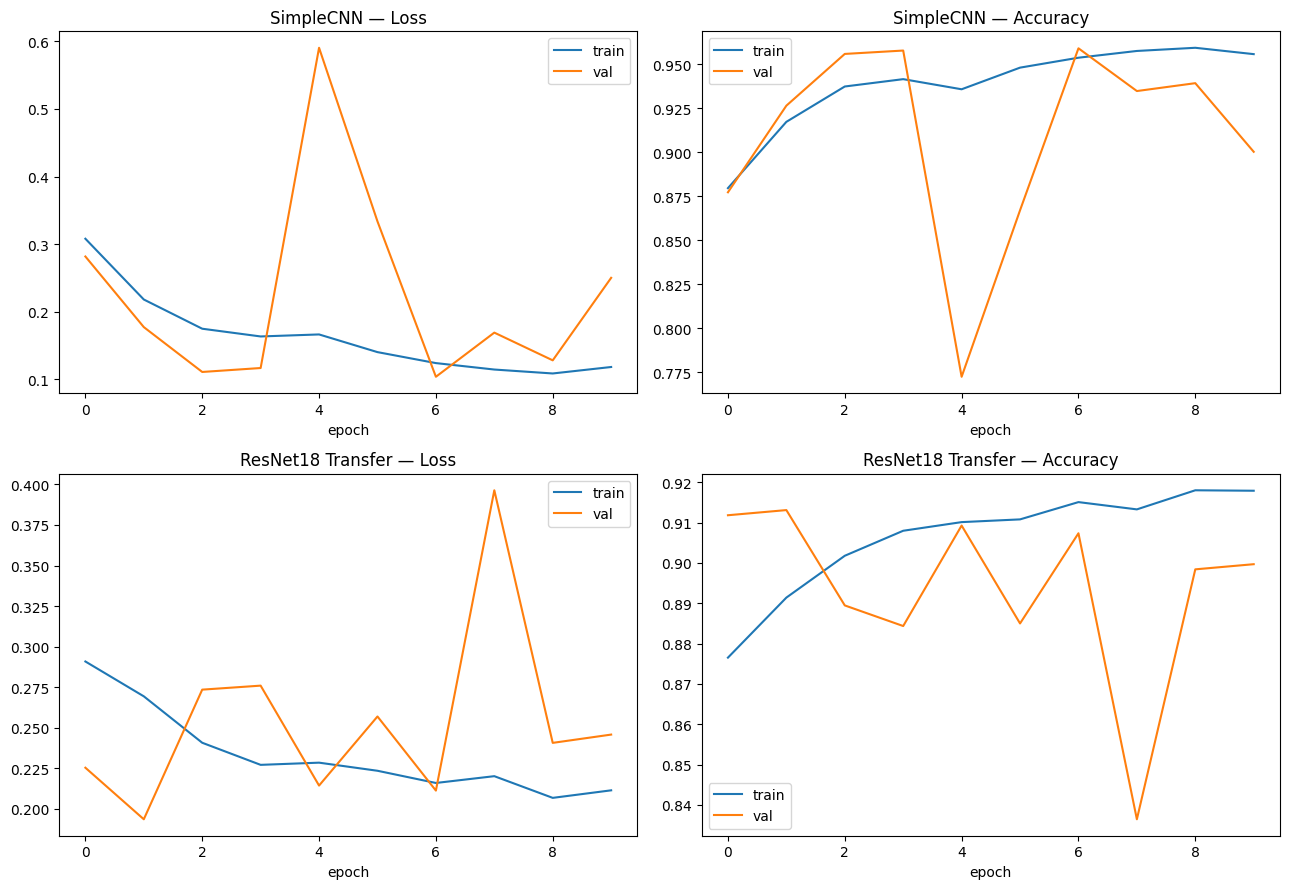

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

axes[0, 0].plot(cnn_history["train_loss"], label="train")
axes[0, 0].plot(cnn_history["val_loss"], label="val")
axes[0, 0].set_title("SimpleCNN — Loss")
axes[0, 0].set_xlabel("epoch"); axes[0, 0].legend()

axes[0, 1].plot(cnn_history["train_acc"], label="train")
axes[0, 1].plot(cnn_history["val_acc"], label="val")
axes[0, 1].set_title("SimpleCNN — Accuracy")
axes[0, 1].set_xlabel("epoch"); axes[0, 1].legend()

axes[1, 0].plot(transfer_history["train_loss"], label="train")
axes[1, 0].plot(transfer_history["val_loss"], label="val")
axes[1, 0].set_title("ResNet18 Transfer — Loss")
axes[1, 0].set_xlabel("epoch"); axes[1, 0].legend()

axes[1, 1].plot(transfer_history["train_acc"], label="train")
axes[1, 1].plot(transfer_history["val_acc"], label="val")
axes[1, 1].set_title("ResNet18 Transfer — Accuracy")
axes[1, 1].set_xlabel("epoch"); axes[1, 1].legend()

plt.tight_layout()
plt.show()


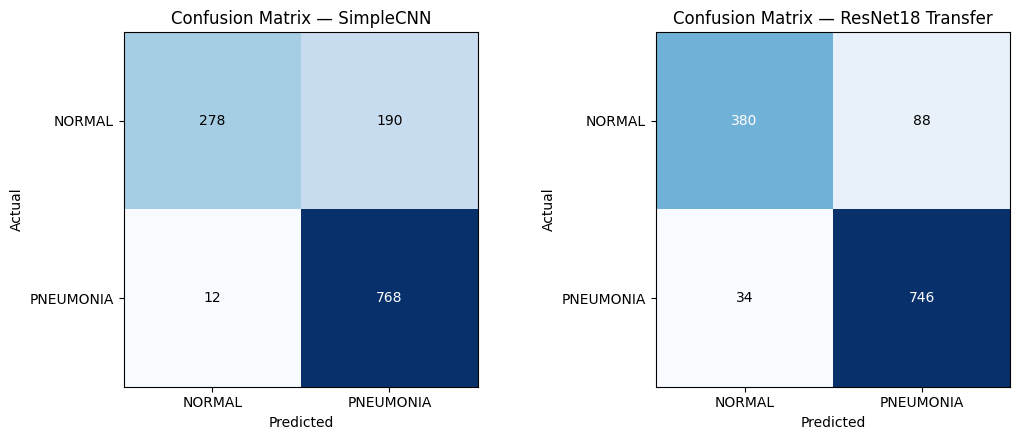

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for ax, (labels, preds, title) in zip(
    axes,
    [(cnn_labels, cnn_preds, "SimpleCNN"), (transfer_labels, transfer_preds, "ResNet18 Transfer")],
):
    cm = confusion_matrix(labels, preds)
    im = ax.imshow(cm, cmap="Blues")
    ax.set_title(f"Confusion Matrix — {title}")
    ax.set_xticks([0, 1]); ax.set_xticklabels(["NORMAL", "PNEUMONIA"])
    ax.set_yticks([0, 1]); ax.set_yticklabels(["NORMAL", "PNEUMONIA"])
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha="center", va="center",
                     color="white" if cm[i, j] > cm.max() / 2 else "black")

plt.tight_layout()
plt.show()


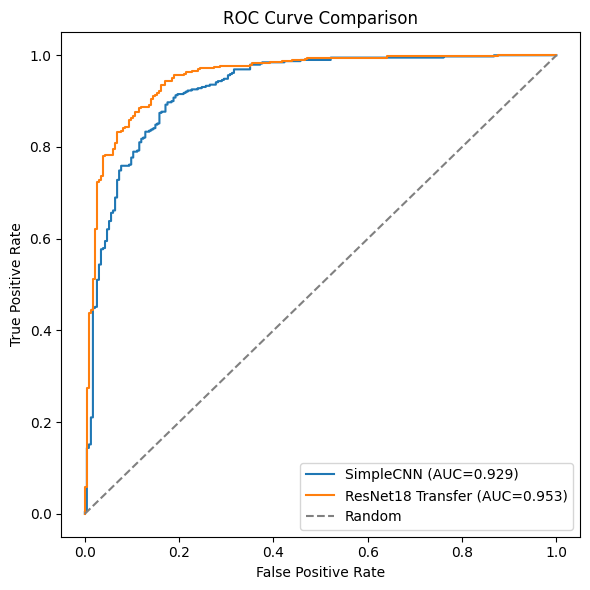

In [20]:
fig, ax = plt.subplots(figsize=(6, 6))

for labels, probs, title in [
    (cnn_labels, cnn_probs, "SimpleCNN"),
    (transfer_labels, transfer_probs, "ResNet18 Transfer"),
]:
    fpr, tpr, _ = roc_curve(labels, probs)
    auc = roc_auc_score(labels, probs)
    ax.plot(fpr, tpr, label=f"{title} (AUC={auc:.3f})")

ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve Comparison")
ax.legend()
plt.tight_layout()
plt.show()


In [21]:
comparison_df = pd.DataFrame(
    {"SimpleCNN (scratch)": cnn_metrics, "ResNet18 (transfer)": transfer_metrics}
).T
comparison_df["trainable_params"] = [n_params_cnn, n_params_transfer]
comparison_df


,accuracy,precision,recall,f1,roc_auc,trainable_params
SimpleCNN (scratch),0.838141,0.801670,0.984615,0.883774,0.928539,405954
ResNet18 (transfer),0.902244,0.894484,0.956410,0.924411,0.953408,65922


## 11. Discussion — how do the results vary?

Fill this in after running the notebook, but the pattern typically observed on this dataset is:

- **Convergence speed:** the transfer-learning model usually reaches high validation accuracy
  within the first 1-3 epochs, because its convolutional filters already encode general visual
  features (edges, textures, shapes) learned from ImageNet — only the small classifier head has
  to be learned. The custom CNN has to learn *all* of its filters from scratch, so it converges
  more slowly and needs more epochs/data to reach comparable performance.
- **Generalisation gap:** the from-scratch CNN, having far fewer prior "visual assumptions,"
  is more prone to overfitting on a training set of only a few thousand images — the gap between
  train and validation accuracy tends to be wider. The frozen-backbone transfer model, with most
  of its parameters fixed, is far less prone to overfitting, since only the head is trainable.
- **Absolute performance:** on chest X-ray pneumonia detection specifically, transfer learning
  from ImageNet tends to give a moderate boost in accuracy/F1/ROC-AUC over a plain CNN of similar
  depth, though the gap is usually smaller than on more complex natural-image tasks — X-rays are
  visually quite different from ImageNet's natural photos, so the transferred low-level features
  (edges/textures) help more than the transferred high-level, object-specific features.
- **Parameter efficiency:** the transfer model achieves its result while training only a small
  fraction of its total parameters (just the new head), whereas the custom CNN trains every
  parameter — an efficiency advantage that matters more as the dataset gets smaller.
- **Recall on PNEUMONIA (the clinically important class):** compare recall/F1 for the PNEUMONIA
  class specifically between the two models — in a diagnostic setting, missed pneumonia cases
  (false negatives) are more costly than false positives, so this is often the more meaningful
  comparison than overall accuracy.

Update the bullet points above with the actual numbers from your run (see the comparison table
in Section 10) to turn this into a concrete, evidence-backed conclusion.


## 12. (Optional) Fine-tuning the transfer model

For a further comparison point, you can unfreeze the last block of ResNet18 and fine-tune it
at a small learning rate, which often closes more of the gap with the frozen-backbone version:


In [22]:
# Optional: fine-tune the last residual block + head at a lower learning rate
# for name, param in transfer_model.named_parameters():
#     if "layer4" in name or "fc" in name:
#         param.requires_grad = True
#
# transfer_model_finetuned, finetune_history = train_model(
#     transfer_model, train_loader, val_loader, epochs=5, lr=1e-5, label="ResNet18-Finetuned"
# )
# finetune_metrics, *_ = evaluate_model(transfer_model_finetuned, test_loader, label="ResNet18 (fine-tuned)")
